In [1]:
from pathlib import Path
import xarray as xr
import matplotlib.pyplot as plt

from holoviews import opts
import panel as pn

import echoshader

In [2]:
path_MVBS = "/Users/wujung/Downloads/prefect_sh2506_MVBS"

In [3]:
MVBS_files = sorted(list(Path(path_MVBS).glob("MVBS_*.zarr")))

In [4]:
len(MVBS_files)

182

In [5]:
MVBS_files[-10:-5]

[PosixPath('/Users/wujung/Downloads/prefect_sh2506_MVBS/MVBS_20250615T200000.zarr'),
 PosixPath('/Users/wujung/Downloads/prefect_sh2506_MVBS/MVBS_20250615T202000.zarr'),
 PosixPath('/Users/wujung/Downloads/prefect_sh2506_MVBS/MVBS_20250615T204000.zarr'),
 PosixPath('/Users/wujung/Downloads/prefect_sh2506_MVBS/MVBS_20250615T210000.zarr'),
 PosixPath('/Users/wujung/Downloads/prefect_sh2506_MVBS/MVBS_20250615T212000.zarr')]

In [6]:
ds_MVBS_combine = xr.open_mfdataset(
    MVBS_files[-10:-5],
    parallel=True,
    coords="minimal",
    data_vars="minimal",
    compat='override',
    chunks={"channel": -1, "ping_time": -1, "depth": -1},  # load everything into 1 chunk
    engine="zarr",  # use zarr engine for reading
)

In [7]:
ds_MVBS_combine["channel"]

<xarray.DataArray 'channel' (channel: 5)> Size: 500B
array(['WBT 400140-15 ES120-7C_ES', 'WBT 400141-15 ES18_ES',
       'WBT 400142-15 ES70-7C_ES', 'WBT 400143-15 ES38B_ES',
       'WBT 400145-15 ES200-7C_ES'], dtype='<U25')
Coordinates:
  * channel  (channel) <U25 500B 'WBT 400140-15 ES120-7C_ES' ... 'WBT 400145-...
Attributes:
    long_name:  Vendor channel ID

In [8]:
ds_MVBS_combine["echo_range"] = ds_MVBS_combine["depth"]

In [9]:
ds_MVBS_combine = ds_MVBS_combine.swap_dims({"depth": "echo_range"})

In [10]:
ds_MVBS_combine["Sv"] = ds_MVBS_combine["Sv"].assign_attrs(
    actual_range=(float(ds_MVBS_combine["Sv"].min().compute()),
                  float(ds_MVBS_combine["Sv"].max().compute()))
)

In [11]:
ds_MVBS_combine["channel"]

<xarray.DataArray 'channel' (channel: 5)> Size: 500B
array(['WBT 400140-15 ES120-7C_ES', 'WBT 400141-15 ES18_ES',
       'WBT 400142-15 ES70-7C_ES', 'WBT 400143-15 ES38B_ES',
       'WBT 400145-15 ES200-7C_ES'], dtype='<U25')
Coordinates:
  * channel  (channel) <U25 500B 'WBT 400140-15 ES120-7C_ES' ... 'WBT 400145-...
Attributes:
    long_name:  Vendor channel ID

In [12]:
ds_MVBS_combine["Sv"].attrs

{'binning_mode': 'physical units',
 'cell_methods': 'ping_time: mean (interval: 5 second comment: ping_time is the interval start) depth: mean (interval: 1.0 meter comment: depth is the interval start)',
 'long_name': 'Mean volume backscattering strength (MVBS, mean Sv re 1 m-1)',
 'ping_time_interval': '5s',
 'range_meter_interval': '1.0m',
 'units': 'dB',
 'actual_range': (-116.12368229087264, 20.11221100867724)}

In [18]:
tricolor = ds_MVBS_combine.eshader.echogram(
    channel=[
        "WBT 400140-15 ES120-7C_ES",
        "WBT 400143-15 ES38B_ES",
        "WBT 400141-15 ES18_ES",
    ],
    vmin=-70,
    vmax=-36,
    rgb_composite=True,
    invert_yaxis=True,
    width=800
)

In [19]:
pn.Row(tricolor)

BokehModel(combine_events=True, render_bundle={'docs_json': {'441ea439-22b9-46f8-ab41-362378d74d62': {'version…

In [15]:
multi_freq = ds_MVBS_combine.eshader.echogram(
    channel=[
        "WBT 400140-15 ES120-7C_ES",
        "WBT 400143-15 ES38B_ES",
        "WBT 400141-15 ES18_ES",
    ],
    vmin=-70,
    vmax=-36,
    rgb_composite=False,
    # invert_yaxis=True,  # this errors out
    width=800,
    cmap="viridis"
)

In [16]:
pn.Row(multi_freq)

BokehModel(combine_events=True, render_bundle={'docs_json': {'70e0e441-82ab-461f-bcdd-ce56648d1175': {'version…

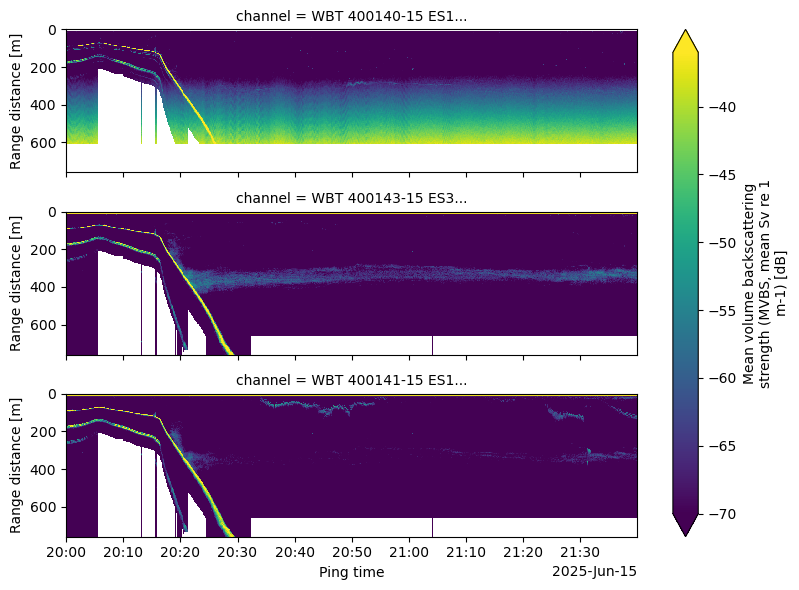

In [17]:
ds_MVBS_combine["Sv"].sel(
    channel=[
        "WBT 400140-15 ES120-7C_ES",
        "WBT 400143-15 ES38B_ES",
        "WBT 400141-15 ES18_ES",
    ]
).plot(
    x="ping_time",
    col="channel",
    col_wrap=1, figsize=(8, 6),
    vmin=-70, vmax=-36, yincrease=False,
)